
📄 DataFrame: df_games
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB

📄 DataFrame: df_users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14306064 entries, 0 to 14306063
Data columns (tot

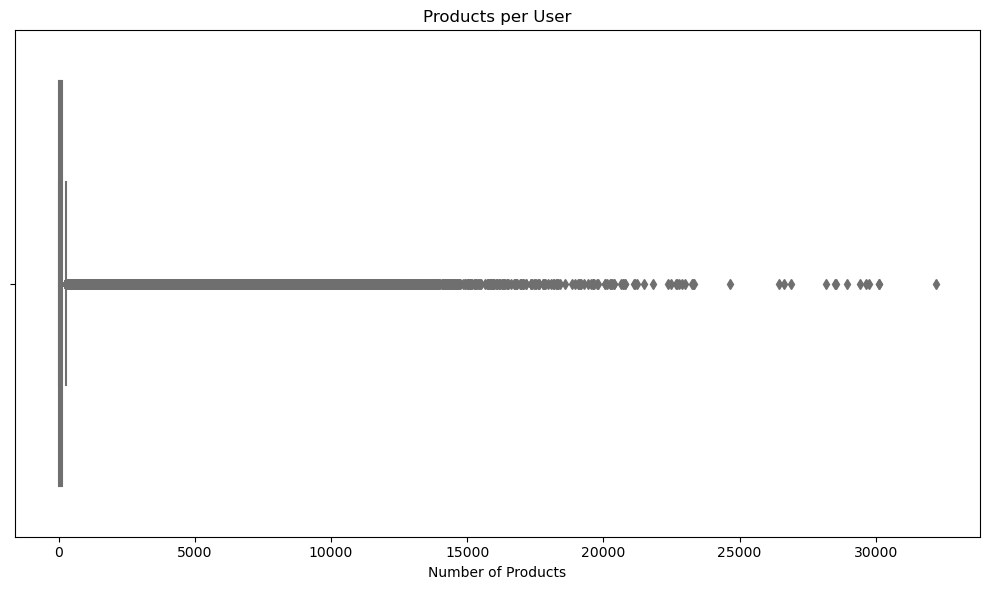

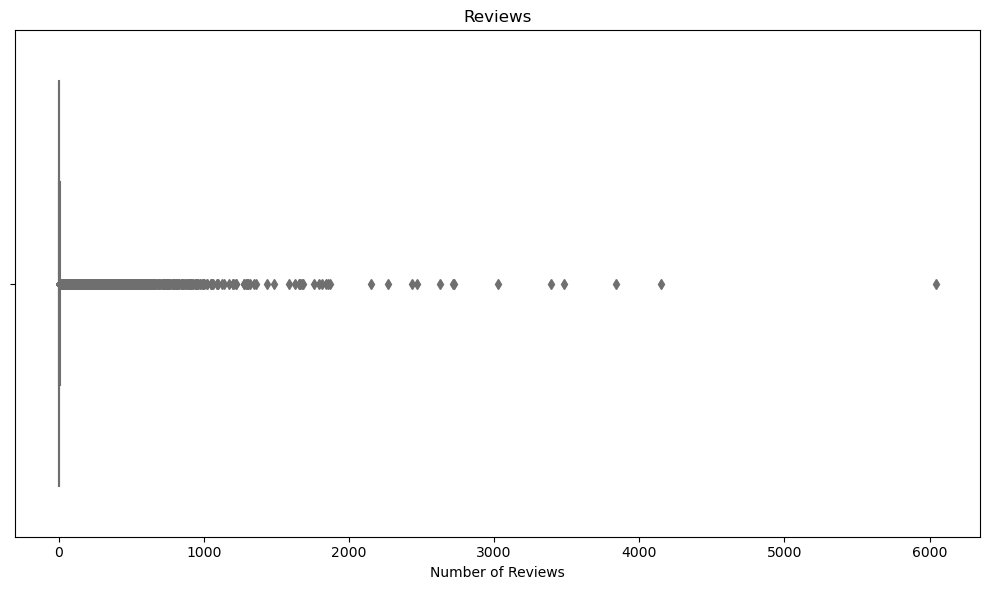

Train Set: 255419 Recommendations
Validation Set: 102627 Recommendations
Test Set: 102627 Recommendations
Cold-Start Test Set: 30311 Users, 13205 Items


In [1]:
%run Preproc.ipynb

In [2]:
import ast
from sklearn.feature_extraction.text import TfidfVectorizer

# ✅ Step 1: Copy and fix tag format
games_processed_all = games_processed.copy()

# 🔄 Convert stringified lists into real lists
games_processed_all["tags"] = games_processed_all["tags"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# ✅ Step 2: Filter out entries with very short or empty tags
games_processed_all = games_processed_all[games_processed_all["tags"].apply(lambda tags: len(tags) > 1)]

# ✅ Step 3: Convert tags to space-separated strings
games_processed_all["tags_text"] = games_processed_all["tags"].apply(lambda tags: " ".join(tags))
games_processed_all = games_processed_all[games_processed_all["tags_text"].str.strip() != ""]

# ✅ Step 4: TF-IDF vectorization
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = vectorizer.fit_transform(games_processed_all["tags_text"])

# ✅ Step 5: Create DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=games_processed_all["app_id"], columns=vectorizer.get_feature_names_out())

print("✅ tfidf_df successfully created with shape:", tfidf_df.shape)

✅ tfidf_df successfully created with shape: (6779, 482)


In [5]:

# ✅ Step 6: Build user profiles using training set and TF-IDF tag vectors

user_profiles_tfidf = {}
for user_id in train_df["user_id"].unique():
    app_ids = train_df[train_df["user_id"] == user_id]["app_id"]
    valid_ids = app_ids[app_ids.isin(tfidf_df.index)]
    vectors = tfidf_df.loc[valid_ids]
    if not vectors.empty:
        user_profiles_tfidf[user_id] = vectors.mean(axis=0).values.reshape(1, -1)

print(f"✅ Built TF-IDF profiles for {len(user_profiles_tfidf)} users.")


✅ Built TF-IDF profiles for 97077 users.


In [6]:

# ✅ recommend_tfidf_contentwith fallback for cold start users

def recommend_tfidf_content(user_id, top_n=10):
    if user_id not in user_profiles_tfidf:
        fallback = games_processed_all.sort_values(by="user_reviews", ascending=False).head(top_n)
        recs = fallback[["app_id", "title"]].copy()
        recs.insert(0, "user_id", user_id)
        return recs

    user_vector = user_profiles_tfidf[user_id]
    similarities = cosine_similarity(user_vector, tfidf_df.values).flatten()

    played = set(train_df[train_df["user_id"] == user_id]["app_id"])
    sorted_indices = similarities.argsort()[::-1]
    recommended_ids = [tfidf_df.index[i] for i in sorted_indices if tfidf_df.index[i] not in played][:top_n]

    recs = games_processed_all[games_processed_all["app_id"].isin(recommended_ids)][["app_id", "title"]].copy()
    recs.insert(0, "user_id", user_id)
    return recs

print("✅ Recommender supports fallback for cold users and can be evaluated.")


✅ Recommender supports fallback for cold users and can be evaluated.


In [9]:

# 🔍 Demo: View a TF-IDF user profile and their top 5 content-based recommendations

# Pick a sample user with a TF-IDF profile
#sample_user_id = next(iter(user_profiles_tfidf.keys()))
# 🔍 Demo: Recommend games for any user (TF-IDF or fallback)

sample_user_id = 1239  # Change this to test any user

if sample_user_id in user_profiles_tfidf:
    # ✅ TF-IDF path
    user_vector = user_profiles_tfidf[sample_user_id]
    similarities = cosine_similarity(user_vector, tfidf_df.values).flatten()

    played = set(train_df[train_df["user_id"] == sample_user_id]["app_id"])
    sorted_indices = similarities.argsort()[::-1]
    recommended_ids = [tfidf_df.index[i] for i in sorted_indices if tfidf_df.index[i] not in played][:5]

    recommended_games = games_processed_all[games_processed_all["app_id"].isin(recommended_ids)][["app_id", "title"]].reset_index(drop=True)

    # Show user's top tags
    user_tag_scores = pd.Series(user_vector.flatten(), index=tfidf_df.columns).sort_values(ascending=False)
    top_user_tags = user_tag_scores.head(10)

    print(f"🧑‍💻 TF-IDF Recommendation for User ID: {sample_user_id}")
    print("\n🔝 Top Tags for this User:")
    display(top_user_tags)

    print("\n🎮 Top 5 Game Recommendations:")
    display(recommended_games)

else:
    # 🧊 Fallback for cold start user
    recommendations = recommend_tfidf_content(sample_user_id, top_n=5)
    print(f"🧊 Fallback Recommendation for Cold Start User ID: {sample_user_id}")
    display(recommendations)


🧑‍💻 TF-IDF Recommendation for User ID: 1239

🔝 Top Tags for this User:


2d              0.105868
soundtrack      0.090983
great           0.086290
co              0.084291
op              0.084291
roguelike       0.079597
singleplayer    0.078394
horror          0.075868
puzzle          0.075659
indie           0.066981
dtype: float64


🎮 Top 5 Game Recommendations:


,app_id,title
0,589500,Shovel Knight: Shovel of Hope
1,1123450,Chicory: A Colorful Tale
2,773090,Lucid Dream Adventure
3,916160,Dreamwalker: Never Fall Asleep
4,465100,LUNA The Shadow Dust


In [8]:
# ✅ Autoencoder-based Content-Based Recommender (Tag Embedding)

from sklearn.neural_network import MLPRegressor
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Use tag matrix from already encoded tags
# Step 1: Use TF-IDF matrix instead of one-hot encoding
tag_matrix = tfidf_df.values
app_ids = tfidf_df.index.values

# Step 2: Train a shallow autoencoder
autoencoder = MLPRegressor(hidden_layer_sizes=(50,), max_iter=2000, random_state=42)
autoencoder.fit(tag_matrix, tag_matrix)

# Step 3: Get latent representations (encoded tag vectors)
encoded_vectors = autoencoder.predict(tag_matrix)
latent_df = pd.DataFrame(encoded_vectors, index=app_ids)


# Step 4: Build user profiles in latent space
user_profiles_autoenc = {}
for user_id in train_df["user_id"].unique():
    app_ids_user = train_df[train_df["user_id"] == user_id]["app_id"]
    valid_ids = app_ids_user[app_ids_user.isin(latent_df.index)]
    user_vector = latent_df.loc[valid_ids].mean(axis=0)
    if not user_vector.isna().any():
        user_profiles_autoenc[user_id] = user_vector.values.reshape(1, -1)

# Step 5: Recommendation function

def recommend_autoencoder_content(user_id, top_n=10):
    if user_id not in user_profiles_autoenc:
        fallback = games_processed_all.sort_values(by="user_reviews", ascending=False).head(top_n)
        recs = fallback[["app_id", "title"]].copy()
        recs.insert(0, "user_id", user_id)
        return recs

    user_vector = user_profiles_autoenc[user_id]
    similarities = cosine_similarity(user_vector, latent_df.values).flatten()

    played = set(train_df[train_df["user_id"] == user_id]["app_id"])
    sorted_indices = similarities.argsort()[::-1]
    recommended_ids = [latent_df.index[i] for i in sorted_indices if latent_df.index[i] not in played][:top_n]

    recs = games_processed_all[games_processed_all["app_id"].isin(recommended_ids)][["app_id", "title"]].copy()
    recs.insert(0, "user_id", user_id)
    return recs



In [10]:
# 🔍 Demo: Recommend games for any user using Autoencoder (with fallback)

sample_user_id = 1239  # Change this to test another user

recommendations = recommend_autoencoder_content(sample_user_id, top_n=5)

if sample_user_id in user_profiles_autoenc:
    print(f"\U0001f9e0 Autoencoder-Based Recommendations for User ID: {sample_user_id}")
        
    # Show top 10 latent dimensions for the user
    user_vector = user_profiles_autoenc[sample_user_id]
    user_latent_scores = pd.Series(user_vector.flatten(), index=[f"latent_{i}" for i in range(user_vector.shape[1])])
    top_latent_features = user_latent_scores.sort_values(ascending=False).head(10)

    print("\n🔝 Top Latent Dimensions for this User (Autoencoder):")
    display(top_latent_features)
else:
    print(f"\U0001f9ca Fallback for Cold Start User ID: {sample_user_id}")

display(recommendations)

🧠 Autoencoder-Based Recommendations for User ID: 1239

🔝 Top Latent Dimensions for this User (Autoencoder):


latent_82     0.084666
latent_332    0.083544
latent_298    0.082030
latent_399    0.081950
latent_384    0.078519
latent_191    0.077694
latent_206    0.077107
latent_3      0.068432
latent_216    0.064158
latent_18     0.063090
dtype: float64

,user_id,app_id,title
1218,1239,1119710,looK INside - Chapter 1
1706,1239,1123450,Chicory: A Colorful Tale
3006,1239,593640,Papetura
3653,1239,922550,keyg
5930,1239,453910,Love is Dead


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from collections import defaultdict
import numpy as np

def evaluate_recommender(model_function, df_test, k=10):
    """
    Evaluate a content-based recommender system using precision, recall, f1, accuracy, precision@k, ndcg@k.
    
    Parameters:
    - model_function: recommendation function taking user_id and top_n=k
    - df_test: test set with user_id and app_id columns
    - k: number of recommendations per user

    Returns:
    - metrics: dictionary with average scores
    """
    true_positives = 0
    total_recommended = 0
    total_relevant = 0

    precision_scores = []
    recall_scores = []
    f1_scores = []
    accuracy_scores = []
    ndcg_scores = []

    users_evaluated = 0

    grouped_test = df_test.groupby("user_id")
    
    for user_id, group in grouped_test:
        true_items = set(group["app_id"])
        if not true_items:
            continue

        recs = model_function(user_id, top_n=k)
        predicted_items = list(recs["app_id"].dropna())
        
        if not predicted_items:
            continue

        y_true = [1 if app_id in true_items else 0 for app_id in predicted_items]
        y_pred = [1] * len(predicted_items)  # recommender always predicts relevance

        # Basic metrics
        precision_scores.append(precision_score(y_true, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_true, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        accuracy_scores.append(accuracy_score(y_true, y_pred))

        # Precision@k
        hits = sum(y_true)
        precision_at_k = hits / k
        precision_scores.append(precision_at_k)

        # NDCG@k
        dcg = sum([int(relevant) / np.log2(idx + 2) for idx, relevant in enumerate(y_true)])
        idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(true_items), k))])
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)

        users_evaluated += 1

    # Aggregate scores
    metrics = {
        "Users Evaluated": users_evaluated,
        "Avg Precision": round(np.mean(precision_scores), 4),
        "Avg Recall": round(np.mean(recall_scores), 4),
        "Avg F1": round(np.mean(f1_scores), 4),
        "Avg Accuracy": round(np.mean(accuracy_scores), 4),
        "Avg NDCG@k": round(np.mean(ndcg_scores), 4)
    }

    return metrics

# Evaluate on the regular test set
results_normal = evaluate_recommender(recommend_autoencoder_content, test_df, k=10)
print(f"\n✅ Evaluation Results (Normal Users): {len(test_df)} Recommendations")
for metric, value in results_normal.items():
    print(f"{metric}: {value}")

# Evaluate on the cold-start user test set
results_cold = evaluate_recommender(recommend_autoencoder_content, cold_user_df, k=10)
print(f"\n🧊 Evaluation Results (Cold-Start Users): {len(cold_user_df)} Users")
for metric, value in results_cold.items():
    print(f"{metric}: {value}")


✅ Evaluation Results (Normal Users): 102627 Recommendations
Users Evaluated: 97081
Avg Precision: 0.0028
Avg Recall: 0.028
Avg F1: 0.0051
Avg Accuracy: 0.0028
Avg NDCG@k: 0.012

🧊 Evaluation Results (Cold-Start Users): 30311 Users
Users Evaluated: 22388
Avg Precision: 0.0241
Avg Recall: 0.2332
Avg F1: 0.0436
Avg Accuracy: 0.0241
Avg NDCG@k: 0.0912


In [14]:
# Evaluate your TF-IDF recommender
# Evaluate on the regular test set
results_normal = evaluate_recommender(recommend_tfidf_content, test_df, k=10)
print(f"\n✅ Evaluation Results (Normal Users): {len(test_df)} Recommendations")
for metric, value in results_normal.items():
    print(f"{metric}: {value}")

# Evaluate on the cold-start user test set
results_cold = evaluate_recommender(recommend_tfidf_content, cold_user_df, k=10)
print(f"\n🧊 Evaluation Results (Cold-Start Users): {len(cold_user_df)} Users")
for metric, value in results_cold.items():
    print(f"{metric}: {value}")


✅ Evaluation Results (Normal Users): 102627 Recommendations
Users Evaluated: 97081
Avg Precision: 0.0032
Avg Recall: 0.0318
Avg F1: 0.0058
Avg Accuracy: 0.0032
Avg NDCG@k: 0.0139

🧊 Evaluation Results (Cold-Start Users): 30311 Users
Users Evaluated: 22388
Avg Precision: 0.0241
Avg Recall: 0.2332
Avg F1: 0.0436
Avg Accuracy: 0.0241
Avg NDCG@k: 0.0912
